# 4장 2강: 순환 신경망 아키텍처 구현
## 2. 순환 신경망 아키텍처 실습

### 2.2 데이터 준비 및 분할

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [5]:


# 네이버 영화 리뷰 데이터셋(NSMC) 로드
# 긍정 리뷰 = 1, 부정 리뷰 = 0
df = pd.read_csv('ratings.txt', sep= '\t')
#df.head()

# 결측치 전처리
df = df.dropna()

# 데이터 분할 (Train: 64%, Valid: 16%, Test: 20%)
# 과적합을 방지하고 정확한 평가를 위해 학습 데이터와 평가 데이터를 분리합니다.
train_tmp_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# 학습용 데이터를 다시 분할하여 검증(Validation) 데이터셋 구축
train_df, val_df = train_test_split(train_tmp_df, test_size = 0.2, random_state=42)

print("훈련세트:", len(train_df))
print("검증세트:", len(val_df))
print("테스트세트:", len(test_df))


훈련세트: 127994
검증세트: 31999
테스트세트: 39999


### 2.3 토큰화 및 파이토치 DataLoader 구축

In [9]:
from collections import Counter
import torch
import torch.nn as nn 
from torch.utils.data import DataLoader, Dataset

# document 항목(후기)에서 공백으로 단어를 쪼개서, 가장 많이 사용되는 단어(토큰)의 20,000개를 추려내겠다.
# 훈련 데이터 기반으로 간단한 공백 기준의 단어 사전(Vocabulary) 구축
vocab_size = 20000
all_words=[]
for text in train_df['document']:
    all_words.extend(text.split())

# 빈도수가 높은 순서대로 단어 정렬 후 고유 인덱스 부여 (0은 패딩, 1은 모르는 단어)
counts = Counter(all_words)
vocab = {word: i+2 for i,(word,_) in enumerate(counts.most_common(vocab_size -2))}

vocab['<PAD>'] = 0 # 자리수 채우는 토큰
vocab['<UNK>'] = 1 # 없는 토큰



# 파이토치 커스텀 데이터셋(Dataset) 클래스 정의
class NSMCDataset(Dataset):
    def __init__(self, df, vocab, max_len=32):
        self.labels = df['label'].values
        self.texts = df['document'].astype(str).values
        self.vocab = vocab
        self.max_len = max_len
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        # 문장을 단어로 쪼개고 숫자 인덱스로 변환 (사전에 없으면 <UNK>인 1로 매핑)
        tokens = text.split()
        ids = [self.vocab.get(token, 1) for token in tokens[:self.max_len]]
        
        # 문장 표준 규격을 위한 고정 크기 패딩(Padding) 처리
        if len(ids) < self.max_len:
            ids += [0] * (self.max_len - len(ids))
            
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

# 데이터셋 인스턴스 생성 및 배치 단위 DataLoader 선언
train_dataset = NSMCDataset(train_df, vocab)
val_dataset = NSMCDataset(val_df, vocab)
test_dataset = NSMCDataset(test_df, vocab)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)



### 2.4 임베딩과 LSTM 모델 설계

In [14]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(SentimentLSTM, self).__init__()

        # 임베딩 레이어
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)

        # LSTM 레이어
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_dim, batch_first=True)

        self.dropout = nn.Dropout(p=0.5)

        # 출력층 256 -> 1 (이진분류)
        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x - (Batch Size, Sequence length)
        embeds = self.embedding(x) # [Batch Size, Sequence Length, Embedding Dim]
        lstm_out,_ = self.lstm(embeds) # [Batch Size, Sequence Length, Hidden Dim]
        # lstm_out, 전체 은닉상태, _ => (이전 은닉상태(모든 타임스텝), 이전 셀상태)

        last_memory = lstm_out[:,-1,:] # 마지막 은닉 상태 (1차원 벡터)

        last_memory = self.dropout(last_memory)

        logits = self.output(last_memory)
        return logits



### 2.5 조기 종료(Early Stopping) 및 모델 평가

현재 연산에 사용 중인 디바이스: cpu

=== 모델 학습 및 검증 시작 ===
Epoch [1/20] | Train Loss: 0.6129 | Val Loss: 0.4950
 => 최적 모델 가중치 저장 완료
Epoch [2/20] | Train Loss: 0.4446 | Val Loss: 0.4539
 => 최적 모델 가중치 저장 완료
Epoch [3/20] | Train Loss: 0.3762 | Val Loss: 0.4536
 => 최적 모델 가중치 저장 완료
Epoch [4/20] | Train Loss: 0.3224 | Val Loss: 0.4794
 => 검증 손실 미개선 (Counter: 1/3)
Epoch [5/20] | Train Loss: 0.2753 | Val Loss: 0.5438
 => 검증 손실 미개선 (Counter: 2/3)
Epoch [6/20] | Train Loss: 0.2360 | Val Loss: 0.5549
 => 검증 손실 미개선 (Counter: 3/3)

[Early Stopping] 6 Epoch에서 학습을 선제 종료합니다.

=== 최종 테스트 데이터셋 평가 시작 ===
최종 테스트 데이터셋 정확도(Test Accuracy): 76.88%



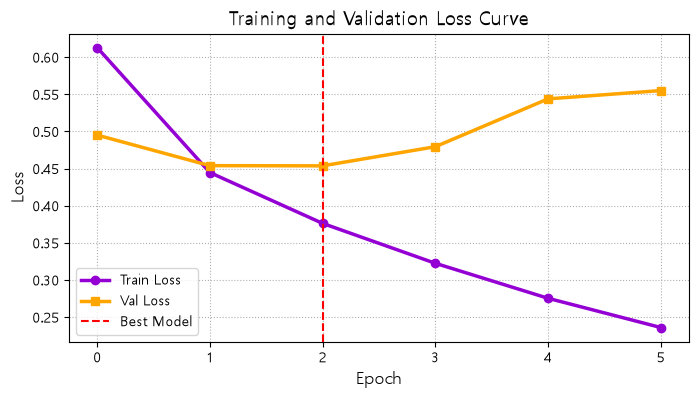

In [15]:
import matplotlib.pyplot as plt
from matplotlib import rc
import platform

# 가속 연산 디바이스(GPU/MPS) 자동 설정
# CUDA(NVIDIA) -> MPS(Mac 인텔/실리콘) -> CPU 순으로 사용 가능한 자원을 체크합니다.
device = torch.device(
    "cuda" if torch.cuda.is_available() else 
    "mps" if torch.backends.mps.is_available() else 
    "cpu"
)
print(f"현재 연산에 사용 중인 디바이스: {device}")

# matplotlib 한글 깨짐 방지 설정 
if platform.system() == 'Darwin':      # macOS 환경
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':   # Windows 환경
    rc('font', family='Malgun Gothic')
    
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 임베딩 파라미터 가중치를 보존할 모델 인스턴스화 및 지정 장치 탑재
vocab_size = 20000  # 사전 구축 크기 가정
embedding_dim = 128
hidden_dim = 256
model = SentimentLSTM(vocab_size, embedding_dim, hidden_dim).to(device)

# 하이퍼파라미터 및 학습 제어 변수 설정
epochs = 20
patience = 3
patience_counter = 0
best_val_loss = float('inf')

train_losses = []
val_losses = []

# 손실 함수 정의 시 BCEWithLogitsLoss를 채택
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("\n=== 모델 학습 및 검증 시작 ===")
for epoch in range(epochs):
    # --- [훈련 모드] ---
    model.train()
    running_train_loss = 0.0
    
    for sequences, labels in train_loader:

        sequences, labels = sequences.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(sequences)
        
        # 손실 계산 (BCEWithLogitsLoss의 입력 규격에 맞춰 레이블을 차원 변환)
        loss = criterion(outputs, labels.float().unsqueeze(1))
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)
    
    # --- [검증 모드] ---
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad(): # 검증 단계에서는 기울기 연산을 차단하여 자원 절약
        for sequences, labels in val_loader:
            sequences, labels = sequences.to(device), labels.to(device)
            outputs = model(sequences)
            loss = criterion(outputs, labels.float().unsqueeze(1))
            running_val_loss += loss.item()
            
    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
    
    # --- [조기 종료 검증] ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_movie_model.pth")
        print(f" => 최적 모델 가중치 저장 완료")
    else:
        patience_counter += 1
        print(f" => 검증 손실 미개선 (Counter: {patience_counter}/{patience})")
        
        if patience_counter >= patience:
            print(f"\n[Early Stopping] {epoch+1} Epoch에서 학습을 선제 종료합니다.")
            break

# --- [최종 테스트셋 평가] ---
# 가장 일반화 성능이 좋았던(검증 손실이 낮았던) 최적 가중치 스냅샷 복원
model.load_state_dict(torch.load("best_movie_model.pth"))
model.eval()

correct = 0
total = 0
threshold = 0.6  # 0.6이상의 값일때 양성으로 판단

print("\n=== 최종 테스트 데이터셋 평가 시작 ===")
with torch.no_grad():
    for sequences, labels in test_loader:
        sequences, labels = sequences.to(device), labels.to(device)
        outputs = model(sequences)
        
        # 모델의 출력 로짓(Logit)을 시그모이드를 통해 0~1 사이의 실제 확률값으로 변환
        probabilities = torch.sigmoid(outputs)
        
        # 신뢰도 임계값(0.6) 이상일 때만 긍정(1)으로 최종 판정
        predictions = (probabilities >= threshold).int()
        
        # 정답 레이블과 비교하여 맞춘 개수 동적 누적 산출
        correct += (predictions == labels.unsqueeze(1)).sum().item()
        total += labels.size(0)

test_accuracy = (correct / total) * 100
print(f"최종 테스트 데이터셋 정확도(Test Accuracy): {test_accuracy:.2f}%\n")

# 에포크별 학습 및 검증 손실 곡선 시각화
plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker='o', color='darkviolet', linewidth=2.5, label='Train Loss')
plt.plot(val_losses, marker='s', color='orange', linewidth=2.5, label='Val Loss')
plt.title("Training and Validation Loss Curve", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.axvline(x=len(train_losses)-patience-1, color='red', linestyle='--', label='Best Model')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()